# Climate Trend Analysis

This notebook explores long-term temperature changes at the Austin, Texas station. The data is an illustrative sample designed to demonstrate a reproducible anomaly workflow.

We define each year's anomaly relative to the 1985-2014 baseline average, then compare the recent period with that baseline.

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_path = project_root / 'data' / 'austin_daily_weather.csv'
output_path = project_root / 'outputs' / 'temperature_anomalies.png'
daily_weather = pd.read_csv(data_path, parse_dates=['time'])
daily_weather['year'] = daily_weather['time'].dt.year
daily_weather['temp'] = daily_weather['temp'].fillna(
    (daily_weather['tmin'] + daily_weather['tmax']) / 2
)
weather = (daily_weather.groupby('year', as_index=False)
           .agg(mean_temperature_c=('temp', 'mean'),
                mean_tmin_c=('tmin', 'mean'),
                mean_tmax_c=('tmax', 'mean'),
                precipitation_mm=('prcp', 'sum')))
weather['station'] = 'Austin Texas'

# Exclude the current, still-in-progress year from every complete-year chart below.
last_complete_year = pd.Timestamp.now().year - 1
weather = weather[weather['year'] <= last_complete_year].copy()
weather.head()

,year,mean_temperature_c,mean_tmin_c,mean_tmax_c,precipitation_mm,station
0,1986,20.826849,15.376712,26.276986,890.2,Austin Texas
1,1987,20.150411,14.485205,25.815616,931.9,Austin Texas
2,1988,20.661202,14.541530,26.780874,488.3,Austin Texas
3,1989,20.337534,14.349041,26.326027,658.1,Austin Texas
4,1990,21.522466,15.575890,27.469041,723.3,Austin Texas


## Establish the baseline

The baseline is the 30-year period from 1985 through 2014. Positive values indicate warmer-than-baseline years; negative values indicate cooler years.

In [8]:
baseline = weather.loc[weather['year'].between(1985, 2014), 'mean_temperature_c'].mean()
weather['temperature_anomaly_c'] = weather['mean_temperature_c'] - baseline
print(f'1985-2014 baseline: {baseline:.2f} C')
weather[['year', 'mean_temperature_c', 'temperature_anomaly_c']].tail()

1985-2014 baseline: 20.81 C


,year,mean_temperature_c,temperature_anomaly_c
35,2021,21.036164,0.222365
36,2022,21.344658,0.530858
37,2023,21.936986,1.123187
38,2024,22.155738,1.341939
39,2025,21.783836,0.970036


## Temperature anomalies over time

The smoothed line helps reveal the direction of change while the bars preserve year-to-year variability.

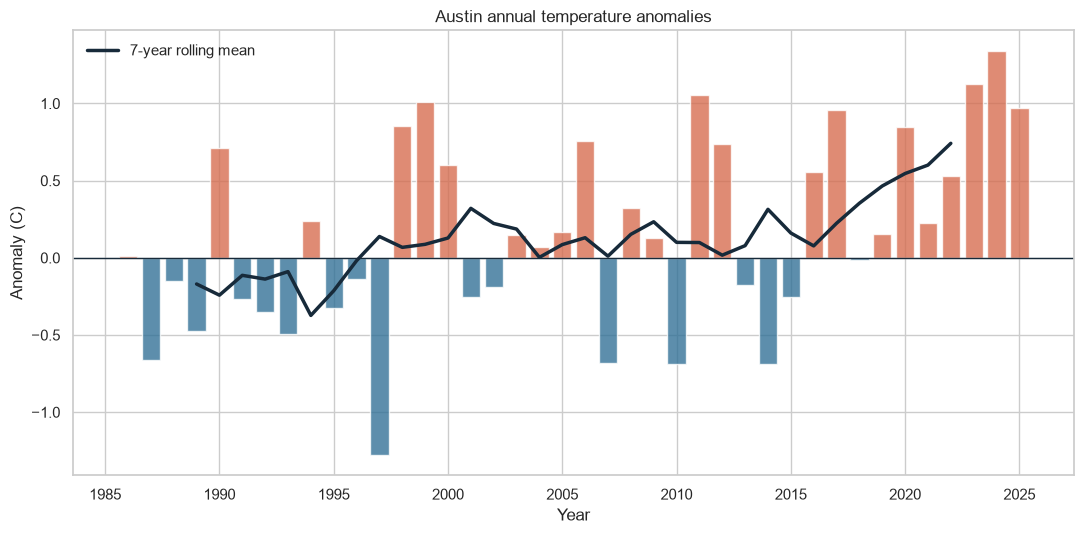

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['#2f6f95' if value < 0 else '#d66b4d' for value in weather['temperature_anomaly_c']]
ax.bar(weather['year'], weather['temperature_anomaly_c'], color=colors, width=0.8, alpha=0.78)
rolling_mean = weather['temperature_anomaly_c'].rolling(7, center=True).mean()
ax.plot(weather['year'], rolling_mean, color='#172a3a', linewidth=2.5, label='7-year rolling mean')
ax.axhline(0, color='#172a3a', linewidth=1)
ax.set(title='Austin annual temperature anomalies', xlabel='Year', ylabel='Anomaly (C)')
ax.legend(frameon=False)
fig.tight_layout()
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=180, bbox_inches='tight')
plt.show()

## Precipitation anomalies

We use the same 1985-2014 baseline period for precipitation. Values are converted from millimeters to inches for the analysis. Positive anomalies represent wetter-than-baseline years, while negative anomalies represent drier years.

1985-2014 precipitation baseline: 34.3 inches


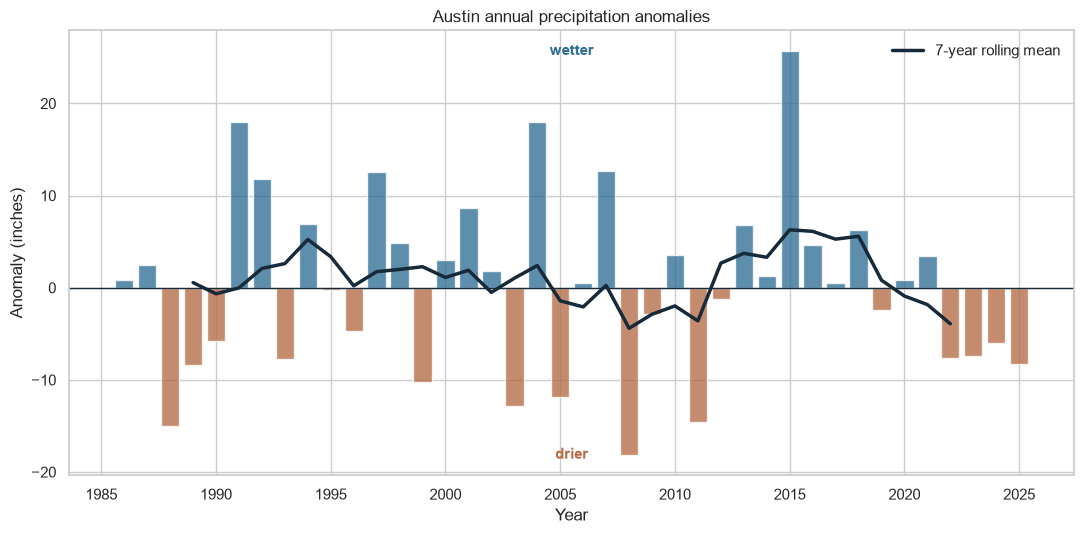

In [10]:
weather['precipitation_inches'] = weather['precipitation_mm'] / 25.4
precipitation_baseline = weather.loc[weather['year'].between(1985, 2014), 'precipitation_inches'].mean()
weather['precipitation_anomaly_inches'] = weather['precipitation_inches'] - precipitation_baseline
print(f'1985-2014 precipitation baseline: {precipitation_baseline:.1f} inches')

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['#2f6f95' if value > 0 else '#b56b45' for value in weather['precipitation_anomaly_inches']]
ax.bar(weather['year'], weather['precipitation_anomaly_inches'], color=colors, width=0.8, alpha=0.78)
rolling_precipitation = weather['precipitation_anomaly_inches'].rolling(7, center=True).mean()
ax.plot(weather['year'], rolling_precipitation, color='#172a3a', linewidth=2.5, label='7-year rolling mean')
ax.axhline(0, color='#172a3a', linewidth=1)
ax.text(0.5, 0.97, 'wetter', transform=ax.transAxes, ha='center', va='top', color='#2f6f95', fontsize=11, fontweight='bold')
ax.text(0.5, 0.03, 'drier', transform=ax.transAxes, ha='center', va='bottom', color='#b56b45', fontsize=11, fontweight='bold')
ax.set(title='Austin annual precipitation anomalies', xlabel='Year', ylabel='Anomaly (inches)')
ax.legend(frameon=False)
fig.tight_layout()
precipitation_output_path = project_root / 'outputs' / 'precipitation_anomalies.png'
fig.savefig(precipitation_output_path, dpi=180, bbox_inches='tight')
plt.show()

## Nighttime Lows (Minimum Temperature Trend)

To determine if night time lows are getting warmer over the past ~40 years (1986–2025), we evaluate annual mean minimum temperatures (`tmin`), baseline anomalies relative to 1985–2014, and the linear warming trend rate per decade in degrees Fahrenheit (°F).

1985-2014 average minimum temperature baseline: 59.17 °F
Nighttime low warming trend: 0.54 °F per decade (2.16 °F over 40 years)


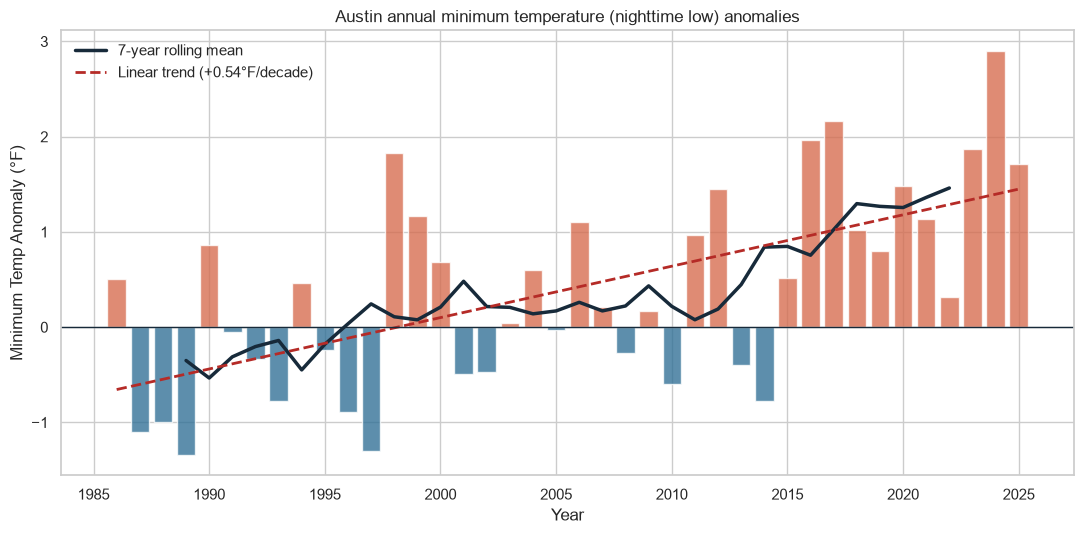

In [11]:
weather_full = weather.copy()
weather_full['mean_tmin_f'] = weather_full['mean_tmin_c'] * 1.8 + 32
tmin_baseline_f = weather_full.loc[weather_full['year'].between(1985, 2014), 'mean_tmin_f'].mean()
weather_full['tmin_anomaly_f'] = weather_full['mean_tmin_f'] - tmin_baseline_f

slope_tmin_f, intercept_tmin_f = np.polyfit(weather_full['year'], weather_full['mean_tmin_f'], 1)

print(f'1985-2014 average minimum temperature baseline: {tmin_baseline_f:.2f} °F')
print(f'Nighttime low warming trend: {slope_tmin_f * 10:.2f} °F per decade ({slope_tmin_f * 40:.2f} °F over 40 years)')

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['#2f6f95' if value < 0 else '#d66b4d' for value in weather_full['tmin_anomaly_f']]
ax.bar(weather_full['year'], weather_full['tmin_anomaly_f'], color=colors, width=0.8, alpha=0.78)
rolling_tmin = weather_full['tmin_anomaly_f'].rolling(7, center=True).mean()
ax.plot(weather_full['year'], rolling_tmin, color='#172a3a', linewidth=2.5, label='7-year rolling mean')
ax.plot(weather_full['year'], (slope_tmin_f * weather_full['year'] + intercept_tmin_f) - tmin_baseline_f, 
        color='#b52b27', linestyle='--', linewidth=2, label=f'Linear trend (+{slope_tmin_f*10:.2f}°F/decade)')
ax.axhline(0, color='#172a3a', linewidth=1)
ax.set(title='Austin annual minimum temperature (nighttime low) anomalies', xlabel='Year', ylabel='Minimum Temp Anomaly (°F)')
ax.legend(frameon=False)
fig.tight_layout()
tmin_output_path = project_root / 'outputs' / 'tmin_anomalies.png'
fig.savefig(tmin_output_path, dpi=180, bbox_inches='tight')
plt.show()

## Summer Nighttime Lows (Astronomical Summer: June 21 – Sept 22)

To analyze nighttime lows specifically during the summer months, we filter daily weather records to astronomical summer (June 21 through September 22) and evaluate the summer baseline and trend in minimum temperatures (`tmin`) in °F.

1985-2014 summer minimum temperature baseline: 73.74 °F
Summer nighttime low warming trend: 0.65 °F per decade (2.61 °F over 40 years)


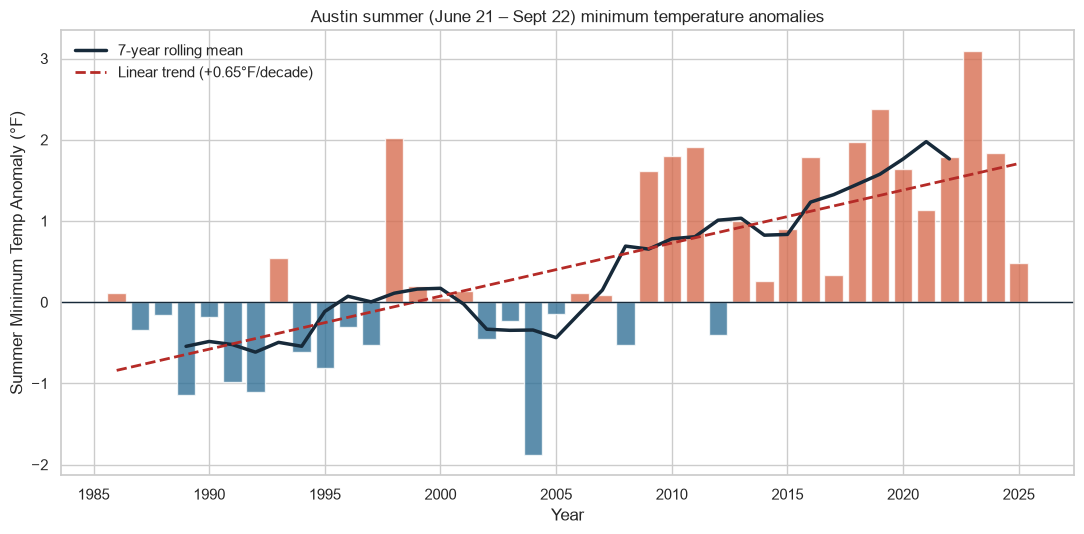

In [12]:
daily_weather['month'] = daily_weather['time'].dt.month
daily_weather['day'] = daily_weather['time'].dt.day

is_summer = (
    ((daily_weather['month'] == 6) & (daily_weather['day'] >= 21)) |
    (daily_weather['month'].isin([7, 8])) |
    ((daily_weather['month'] == 9) & (daily_weather['day'] <= 22))
)
summer_df = daily_weather[is_summer].copy()
summer_df['tmin_f'] = summer_df['tmin'] * 1.8 + 32

last_complete_year = pd.Timestamp.now().year - 1
summer_yearly = (summer_df[summer_df['year'] <= last_complete_year]
                 .groupby('year', as_index=False)
                 .agg(mean_summer_tmin_f=('tmin_f', 'mean')))

summer_baseline_f = summer_yearly.loc[summer_yearly['year'].between(1985, 2014), 'mean_summer_tmin_f'].mean()
summer_yearly['summer_tmin_anomaly_f'] = summer_yearly['mean_summer_tmin_f'] - summer_baseline_f

slope_summer_f, intercept_summer_f = np.polyfit(summer_yearly['year'], summer_yearly['mean_summer_tmin_f'], 1)

print(f'1985-2014 summer minimum temperature baseline: {summer_baseline_f:.2f} °F')
print(f'Summer nighttime low warming trend: {slope_summer_f * 10:.2f} °F per decade ({slope_summer_f * 40:.2f} °F over 40 years)')

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['#2f6f95' if value < 0 else '#d66b4d' for value in summer_yearly['summer_tmin_anomaly_f']]
ax.bar(summer_yearly['year'], summer_yearly['summer_tmin_anomaly_f'], color=colors, width=0.8, alpha=0.78)
rolling_summer_tmin = summer_yearly['summer_tmin_anomaly_f'].rolling(7, center=True).mean()
ax.plot(summer_yearly['year'], rolling_summer_tmin, color='#172a3a', linewidth=2.5, label='7-year rolling mean')
ax.plot(summer_yearly['year'], (slope_summer_f * summer_yearly['year'] + intercept_summer_f) - summer_baseline_f, 
        color='#b52b27', linestyle='--', linewidth=2, label=f'Linear trend (+{slope_summer_f*10:.2f}°F/decade)')
ax.axhline(0, color='#172a3a', linewidth=1)
ax.set(title='Austin summer (June 21 – Sept 22) minimum temperature anomalies', xlabel='Year', ylabel='Summer Minimum Temp Anomaly (°F)')
ax.legend(frameon=False)
fig.tight_layout()
summer_tmin_output_path = project_root / 'outputs' / 'tmin_nh_summer_anomalies.png'
fig.savefig(summer_tmin_output_path, dpi=180, bbox_inches='tight')
plt.show()

## Takeaway

1. **Overall Temperature**: The Austin record demonstrates a gradual increase in annual mean temperature, with the warmest anomalies concentrated in recent years.
2. **Nighttime Lows**: Yes, night time lows are getting consistently warmer. Over the 40-year record (1986–2025), annual minimum temperatures (`tmin`) have increased at a rate of approximately **+0.54°F per decade** (+0.30°C/decade), representing an estimated total increase of **~2.16°F (~1.2°C)**.
3. **Summer Nighttime Lows**: Nighttime warming is even more pronounced during astronomical summer (June 21 – Sept 22), warming at **+0.65°F per decade** (total increase of **~2.61°F** over 40 years).
4. **Precipitation**: Precipitation varies significantly year to year with no clear long-term linear trend.